In [28]:
import pandas as pd

# Input files
PROBE_ROWS_PATH = "/content/probe_results_rows.csv"
TOPUP_ROWS_PATH = "/content/probe_results_topup_rows.csv"

# Output file
OUT_PATH = "/content/probe_results_combined.csv"

TIME_COL_CANDIDATES = ["start_time_utc", "timestamp", "time", "created_at", "start_time", "ts"]


def pick_existing_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    raise ValueError(f"Could not find a time column. Found columns: {sorted(df.columns)}")


def parse_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


probe = pd.read_csv(PROBE_ROWS_PATH)
topup = pd.read_csv(TOPUP_ROWS_PATH)

probe_time_col = pick_existing_col(probe, TIME_COL_CANDIDATES)
topup_time_col = pick_existing_col(topup, TIME_COL_CANDIDATES)

probe[probe_time_col] = parse_utc(probe[probe_time_col])
topup[topup_time_col] = parse_utc(topup[topup_time_col])

probe = probe.loc[probe[probe_time_col].notna()].copy()
topup = topup.loc[topup[topup_time_col].notna()].copy()

if topup_time_col != probe_time_col:
    topup = topup.rename(columns={topup_time_col: probe_time_col})

time_col = probe_time_col

combined = pd.concat([probe, topup], ignore_index=True)
combined = combined.sort_values(time_col, kind="mergesort").reset_index(drop=True)

# Save
combined.to_csv(OUT_PATH, index=False)

print(f"Saved combined file to: {OUT_PATH}")
print(f"Rows in probe file: {len(probe)}")
print(f"Rows in topup file: {len(topup)}")
print(f"Rows in combined file: {len(combined)}")
print(f"Start time: {combined[time_col].min()}")
print(f"End time:   {combined[time_col].max()}")

Saved combined file to: /content/probe_results_combined.csv
Rows in probe file: 6412
Rows in topup file: 1099
Rows in combined file: 7511
Start time: 2026-02-07 02:53:13.958572+00:00
End time:   2026-02-19 04:14:17.608585+00:00


In [4]:
!pip install shap

In [7]:
import argparse
import json
import warnings
import numpy as np
import pandas as pd
from collections import deque

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score

import shap

warnings.filterwarnings("ignore", category=UserWarning)

In [8]:
# ============================================================
# Config
# ============================================================
CSV_PATH = "/content/probe_results_combined.csv"

TIME_COL = "start_time_utc"
CREATED_COL = "created_at"
EVENT_TIME_COL = "event_time"

MAX_HOURS_PER_RUN = 5
TEST_FRACTION = 0.20
RANDOM_STATE = 42

ALPHA_PRIOR = 0.5
BETA_PRIOR = 2.0

POOL_COLS = ["provider", "region", "instance_type"]

TARGET_RATE_COL = "y_block_rate"
TARGET_COUNT_COL = "y_block_count"
TARGET_BIN_COL = "y_block_bin"
TARGET_HORIZON_COL = "y_block_horizon"

CALIB_FRACTION_WITHIN_TRAIN_FULL = 0.15

ECE_BINS = 20
EPS = 1e-15

EWMA_HALF_LIFE_H = 24.0
LAST24_WINDOW_H = 24.0
K_GRID = [0.0, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0]

In [9]:
# ============================================================
# Fixed tuned parameters
# ============================================================
FIXED_ALPHA = 0.9838235589992128
FIXED_L2_REGULARIZATION = 0.8378401206547694
FIXED_MAX_DEPTH = 4
FIXED_MAX_LEAF_NODES = 5
FIXED_MIN_SAMPLES_LEAF = 649
FIXED_TEMP = 1.406058625756019

DELTA_CAP = 2.0

SHAP_MAX_SAMPLES = 2000
SHAP_TOP_N = 20

In [10]:
# ============================================================
# Fixed lookup baseline
# ============================================================
FIXED_BASELINE = {
    "east": {
        "c6i.large": 0.20,
        "m6a.large": 0.075,
        "t3a.large": 0.20,
    },
    "west": {
        "c6i.large": 0.175,
        "m6a.large": 0.025,
        "t3a.large": 0.025,
    },
}

RUN_ID_COL = "run_id"

In [11]:
# ============================================================
# Helpers / Metrics
# ============================================================
def safe_parse_dt(s):
    try:
        return pd.to_datetime(s, utc=True)
    except Exception:
        return pd.NaT


def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z, dtype=float)
    m = (z >= 0)
    out[m] = 1.0 / (1.0 + np.exp(-z[m]))
    ez = np.exp(z[~m])
    out[~m] = ez / (1.0 + ez)
    return out


def logit(p, eps=EPS):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def brier_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean((p - y) ** 2))


def mae_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean(np.abs(p - y)))


def log_loss_fractional(y_true, p_pred, eps=EPS):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), eps, 1.0 - eps)
    ll = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return float(np.mean(ll))


def ece_score(y_true, p_pred, n_bins=20):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    bin_ids = np.minimum(np.digitize(p, edges, right=False) - 1, n_bins - 1)
    bin_ids = np.maximum(bin_ids, 0)

    ece = 0.0
    N = len(y)
    for b in range(n_bins):
        m = (bin_ids == b)
        nb = int(np.sum(m))
        if nb == 0:
            continue
        pred_b = float(np.mean(p[m]))
        true_b = float(np.mean(y[m]))
        ece += (nb / max(1, N)) * abs(pred_b - true_b)
    return float(ece)


def auc_safe(y_bin, p_pred):
    try:
        return float(roc_auc_score(np.asarray(y_bin, int), np.asarray(p_pred, float)))
    except Exception:
        return float("nan")


def print_metrics_block(title, y_rate, y_bin, p_model, global_q, extra_baselines=None):
    y_rate = np.asarray(y_rate, float)
    y_bin = np.asarray(y_bin, int)
    p_model = np.asarray(p_model, float)

    p0 = np.zeros_like(p_model)
    pg = np.full_like(p_model, float(np.clip(global_q, EPS, 1.0 - EPS)))

    rows = [
        ("model", p_model),
        ("global_avg", pg),
        ("always_0", p0),
    ]

    if extra_baselines:
        for name, p in extra_baselines.items():
            p = np.asarray(p, float)
            if len(p) == len(p_model):
                rows.append((str(name), np.clip(p, EPS, 1.0 - EPS)))

    print("\n==============================")
    print(title)
    print("==============================")
    for name, p in rows:
        print(
            f"{name:<14} -> "
            f"Brier: {brier_fractional(y_rate, p):.6f} | "
            f"LogLoss: {log_loss_fractional(y_rate, p):.6f} | "
            f"MAE: {mae_fractional(y_rate, p):.6f} | "
            f"ECE: {ece_score(y_rate, p, n_bins=ECE_BINS):.6f} | "
            f"AUC: {auc_safe(y_bin, np.clip(p, 0, 1)):.3f}"
        )

In [12]:
# ============================================================
# Temperature scaling
# ============================================================
def apply_temperature(p, temp):
    z = logit(p, eps=EPS)
    z = z / float(max(1e-9, temp))
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)

In [13]:
# ============================================================
# Fixed lookup baseline helpers
# ============================================================
def _norm_region_bucket(region):
    r = str(region).strip().lower()
    if "east" in r:
        return "east"
    if "west" in r:
        return "west"
    return None


def fixed_lookup_prob(region, instance_type, fallback):
    bucket = _norm_region_bucket(region)
    it = str(instance_type).strip().lower()
    if bucket is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    p = FIXED_BASELINE.get(bucket, {}).get(it, None)
    if p is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    return float(np.clip(p, EPS, 1.0 - EPS))


def fixed_lookup_series(df, fallback):
    return np.array(
        [fixed_lookup_prob(r, it, fallback) for r, it in zip(df["region"].values, df["instance_type"].values)],
        dtype=float,
    )

In [14]:
# ============================================================
# Load & unpack launch-time features
# ============================================================
def load_raw(path):
    df = pd.read_csv(path)
    print(f"Loaded rows: {len(df)}")

    df = df.reset_index(drop=True).copy()
    df[RUN_ID_COL] = np.arange(len(df), dtype=np.int64)

    if TIME_COL in df.columns:
        df[TIME_COL] = df[TIME_COL].apply(safe_parse_dt)
    if CREATED_COL in df.columns:
        df[CREATED_COL] = df[CREATED_COL].apply(safe_parse_dt)

    if "features_snapshot" in df.columns:
        def unpack_json(x):
            if isinstance(x, dict):
                return x
            if pd.isna(x):
                return {}
            try:
                return json.loads(x)
            except Exception:
                return {}

        fs = df["features_snapshot"].apply(unpack_json)
        df["fs_launch_local_hour"] = fs.apply(lambda d: d.get("launch_local_hour", np.nan))
        df["fs_launch_utc_hour"] = fs.apply(lambda d: d.get("launch_utc_hour", np.nan))
        df["fs_launch_dow"] = fs.apply(lambda d: d.get("launch_dow", np.nan))
        df["fs_price_zscore_6h"] = fs.apply(lambda d: d.get("price_zscore_6h", np.nan))

    out_norm = df.get("outcome", "").astype(str).str.strip().str.lower()
    df["is_launch_failed_int"] = out_norm.str.contains("launchfailed", na=False).astype(int)

    for c in POOL_COLS:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    if "spot_price_usd" not in df.columns:
        df["spot_price_usd"] = np.nan

    return df

In [15]:
# ============================================================
# Expand launched rows into 1-hour slices with y_1h
# ============================================================
def make_hour_slices(df):
    need = [TIME_COL, "duration_minutes", "interrupted", RUN_ID_COL]
    for c in need:
        if c not in df.columns:
            df[c] = np.nan

    launched_mask = df["is_launch_failed_int"] == 0
    elig = df[launched_mask & df[TIME_COL].notna()].copy()

    rows = []
    for _, r in elig.iterrows():
        t0 = r[TIME_COL]
        dur = r.get("duration_minutes", np.nan)
        intr = bool(r.get("interrupted", False))
        rid = r.get(RUN_ID_COL)

        if pd.isna(dur):
            continue

        total_minutes = float(dur)
        max_slices = int(np.ceil(min(total_minutes, MAX_HOURS_PER_RUN * 60) / 60.0))
        if max_slices <= 0:
            continue

        for k in range(max_slices):
            slice_start = t0 + pd.Timedelta(hours=k)
            lo = k * 60.0
            hi = (k + 1) * 60.0

            if intr and (lo < total_minutes <= hi):
                y = 1
            elif total_minutes > hi or (not intr and total_minutes >= hi):
                y = 0
            else:
                continue

            row = r.to_dict()
            row[EVENT_TIME_COL] = slice_start
            row["slice_k"] = k
            row["y_1h"] = y
            row[RUN_ID_COL] = rid
            rows.append(row)

    return pd.DataFrame(rows)


def add_time_features(d):
    d = d.copy()
    dt = pd.to_datetime(d[EVENT_TIME_COL], utc=True)

    hour = dt.dt.hour.astype(float)
    dow = dt.dt.weekday.astype(float)
    d["sin_hour"] = np.sin(2 * np.pi * hour / 24.0)
    d["cos_hour"] = np.cos(2 * np.pi * hour / 24.0)
    d["sin_dow"] = np.sin(2 * np.pi * dow / 7.0)
    d["cos_dow"] = np.cos(2 * np.pi * dow / 7.0)

    d["is_weekend"] = (dt.dt.weekday >= 5).astype(int)

    h_int = dt.dt.hour.astype(int).values
    tod = np.zeros(len(d), dtype=int)
    tod[(h_int >= 6) & (h_int < 12)] = 1
    tod[(h_int >= 12) & (h_int < 18)] = 2
    tod[(h_int >= 18) & (h_int < 24)] = 3
    d["tod_bin"] = tod

    return d


In [16]:
# ============================================================
# Leak-proof split by run_id
# ============================================================
def time_split_by_run_with_gap(d_slices, test_fraction=0.2, block_hours=6):
    if RUN_ID_COL not in d_slices.columns:
        raise ValueError("Missing run_id in slices; cannot do leak-proof split.")

    df = d_slices.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()

    g = df.groupby(RUN_ID_COL, sort=False)
    run_min = g[EVENT_TIME_COL].min()
    run_max = g[EVENT_TIME_COL].max()

    runs = pd.DataFrame({
        RUN_ID_COL: run_min.index.values,
        "run_min_t": pd.to_datetime(run_min.values, utc=True),
        "run_max_t": pd.to_datetime(run_max.values, utc=True),
    }).sort_values("run_min_t").reset_index(drop=True)

    if len(runs) < 10:
        raise ValueError("Too few runs after slicing to split reliably.")

    split_idx = int((1.0 - float(test_fraction)) * len(runs))
    split_idx = min(max(split_idx, 1), len(runs) - 2)
    split_time = pd.to_datetime(runs.loc[split_idx, "run_min_t"], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    train_end_time = split_time - gap

    train_run_ids = runs.loc[runs["run_max_t"] <= train_end_time, RUN_ID_COL].values
    test_run_ids = runs.loc[runs["run_min_t"] > split_time, RUN_ID_COL].values

    train_full = df[df[RUN_ID_COL].isin(train_run_ids)].copy().reset_index(drop=True)
    test = df[df[RUN_ID_COL].isin(test_run_ids)].copy().reset_index(drop=True)

    dropped = len(runs) - (len(train_run_ids) + len(test_run_ids))

    print(
        f"✅ Run-split sizes: train_full={len(train_full)} test={len(test)} "
        f"(gap={block_hours}h, dropped_runs={dropped})"
    )
    if len(train_full) == 0 or len(test) == 0:
        raise ValueError("Empty train_full or test after enforcing run-split + gap.")
    return train_full, test

In [17]:
# ============================================================
# Label construction
# ============================================================
def add_pool_block_rate_target_within_df(d, block_hours):
    d = d.copy().reset_index(drop=True)
    d = d.sort_values(POOL_COLS + [EVENT_TIME_COL]).reset_index(drop=True)

    times = pd.to_datetime(d[EVENT_TIME_COL], utc=True).values
    y1 = d["y_1h"].astype(int).values

    n = len(d)
    y_block_count = np.zeros(n, dtype=float)
    y_block_horizon = np.zeros(n, dtype=float)
    H = pd.Timedelta(hours=block_hours)

    grp = d.groupby(POOL_COLS, sort=False, group_keys=False)
    for _, idx in grp.groups.items():
        idx_arr = np.asarray(idx, dtype=int)
        if len(idx_arr) == 0:
            continue

        t_pool = times[idx_arr]
        y_pool = y1[idx_arr]
        L = len(idx_arr)
        cum = np.concatenate([[0], np.cumsum(y_pool)])

        e = 0
        for i in range(L):
            t_end = t_pool[i] + H
            while e < L and t_pool[e] < t_end:
                e += 1
            horizon = e - i
            count = float(cum[e] - cum[i])
            y_block_horizon[idx_arr[i]] = float(horizon)
            y_block_count[idx_arr[i]] = count

    with np.errstate(divide="ignore", invalid="ignore"):
        y_block_rate = np.where(y_block_horizon > 0, y_block_count / y_block_horizon, 0.0)

    d[TARGET_COUNT_COL] = y_block_count
    d[TARGET_RATE_COL] = y_block_rate
    d[TARGET_BIN_COL] = (y_block_count > 0).astype(int)
    d[TARGET_HORIZON_COL] = y_block_horizon

    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    return d


def split_train_full_into_core_gap_calib(train_full_raw, block_hours, calib_frac=0.15):
    df = train_full_raw.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    n = len(df)
    n_cal = int(np.ceil(calib_frac * n))
    n_cal = max(1, min(n_cal, n - 1))

    calib_start_idx = n - n_cal
    calib_start_time = pd.to_datetime(df.loc[calib_start_idx, EVENT_TIME_COL], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    core_end_time = calib_start_time - gap

    t = pd.to_datetime(df[EVENT_TIME_COL], utc=True)
    train_core_raw = df[t <= core_end_time].copy().reset_index(drop=True)
    calib_raw = df[t >= calib_start_time].copy().reset_index(drop=True)

    if len(train_core_raw) == 0 or len(calib_raw) == 0:
        raise ValueError("Empty train_core or calib after enforcing core/calib gap.")

    print(f"Train_full split (gap={block_hours}h): train_core={len(train_core_raw)} calib={len(calib_raw)}")
    return train_core_raw, calib_raw


def compute_global_q(train_df):
    return float(
        (train_df[TARGET_COUNT_COL].sum() + ALPHA_PRIOR) /
        (train_df[TARGET_HORIZON_COL].sum() + ALPHA_PRIOR + BETA_PRIOR)
    )


In [18]:
# ============================================================
# Online EWMA stats
# ============================================================
def ewma_alpha(half_life_h, dt_h):
    half_life_h = float(max(1e-9, half_life_h))
    lam = np.log(2.0) / half_life_h
    a = 1.0 - np.exp(-lam * float(max(0.0, dt_h)))
    return float(np.clip(a, 0.0, 1.0))


class OnlineEWMA:
    def __init__(self, half_life_h=24.0):
        self.half_life_h = float(half_life_h)
        self.mu = {}
        self.neff = {}
        self.last_t = {}

    def update_one(self, key, t_now, y):
        t_now = pd.to_datetime(t_now, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        if key not in self.mu:
            self.mu[key] = y
            self.neff[key] = 1.0
            self.last_t[key] = t_now
            return

        dt_h = float((t_now - self.last_t[key]) / np.timedelta64(1, "h"))
        dt_h = max(0.0, min(dt_h, 168.0))
        a = ewma_alpha(self.half_life_h, dt_h)

        self.mu[key] = (1.0 - a) * self.mu[key] + a * y
        self.neff[key] = (1.0 - a) * self.neff[key] + 1.0
        self.last_t[key] = t_now

    def get(self, key):
        if key not in self.mu:
            return None, 0.0
        return float(self.mu[key]), float(self.neff[key])


def build_online_ewma_features(df_seq, block_hours, global_fallback):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values

    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)

    pending = deque()
    base_pool = np.zeros(len(df), float)
    base_glob = np.zeros(len(df), float)
    neff_pool = np.zeros(len(df), float)

    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(df.loc[j, TARGET_RATE_COL])
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(k, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_fallback

        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        base_pool[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))
        base_glob[i] = float(np.clip(mu_g, EPS, 1.0 - EPS))
        neff_pool[i] = float(max(0.0, ne_p))

    return base_pool, base_glob, neff_pool


def shrink_pool_to_global(mu_p, mu_g, ne_p, K):
    ne_p = float(max(0.0, ne_p))
    K = float(max(0.0, K))
    w = 0.0 if (ne_p + K) <= 1e-12 else (ne_p / (ne_p + K))
    return float(np.clip(w * mu_p + (1.0 - w) * mu_g, EPS, 1.0 - EPS))

In [19]:
# ============================================================
# Online last24 baseline
# ============================================================
class OnlineWindowMean:
    def __init__(self, window_h=24.0):
        self.window_h = float(window_h)
        self.q = {}
        self.sumy = {}
        self.cnt = {}

    def _ensure(self, key):
        if key not in self.q:
            self.q[key] = deque()
            self.sumy[key] = 0.0
            self.cnt[key] = 0

    def add(self, key, t, y):
        self._ensure(key)
        t = pd.to_datetime(t, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        self.q[key].append((t, y))
        self.sumy[key] += y
        self.cnt[key] += 1

    def prune(self, key, t_ref):
        if key not in self.q:
            return
        t_ref = pd.to_datetime(t_ref, utc=True)
        cutoff = t_ref - pd.Timedelta(hours=float(self.window_h))
        dq = self.q[key]
        while dq and dq[0][0] <= cutoff:
            _, y0 = dq.popleft()
            self.sumy[key] -= float(y0)
            self.cnt[key] -= 1
        if self.cnt[key] <= 0:
            self.sumy[key] = 0.0
            self.cnt[key] = 0

    def mean_and_count(self, key, t_ref):
        self._ensure(key)
        self.prune(key, t_ref)
        if self.cnt[key] <= 0:
            return None, 0
        return float(self.sumy[key] / max(1, self.cnt[key])), int(self.cnt[key])


def build_last24_baseline_prequential(df_seq, block_hours, global_fallback, window_h=24.0):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values
    y = df[TARGET_RATE_COL].astype(float).values

    wm_pool = OnlineWindowMean(window_h)
    wm_glob = OnlineWindowMean(window_h)
    pending = deque()

    p_last24 = np.zeros(len(df), float)

    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        release_cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= release_cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(y[j], 0.0, 1.0))
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())
            wm_pool.add(k, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

        mu_g, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g is None:
            mu_g = float(global_fallback)

        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p is None:
            mu_p = float(mu_g)

        p_last24[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

    return p_last24


In [20]:
# ============================================================
# Model helpers
# ============================================================
def feature_lists():
    cat_all = ["provider", "region", "instance_type"]
    num_all = [
        "slice_k",
        "sin_hour", "cos_hour", "sin_dow", "cos_dow",
        "is_weekend",
        "spot_price_usd",
        "fs_price_zscore_6h",
        "fs_launch_local_hour", "fs_launch_utc_hour",
        "tod_bin",
        "pool_neff",
        "p_base",
    ]
    return cat_all, num_all


def get_active_cat_cols(feat_cols, cat_cols):
    return [c for c in cat_cols if c in feat_cols]


def build_X(df, feat_cols, cat_cols, columns_like=None):
    active_cat_cols = get_active_cat_cols(feat_cols, cat_cols)
    X = pd.get_dummies(df[feat_cols].copy(), columns=active_cat_cols, dummy_na=True)

    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    X = X.fillna(0.0)

    if columns_like is not None:
        X = X.reindex(columns=columns_like, fill_value=0.0)

    return X.astype(np.float64)


def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error",
        max_depth=FIXED_MAX_DEPTH,
        max_leaf_nodes=FIXED_MAX_LEAF_NODES,
        learning_rate=0.03,
        max_iter=1200,
        min_samples_leaf=FIXED_MIN_SAMPLES_LEAF,
        l2_regularization=FIXED_L2_REGULARIZATION,
        random_state=RANDOM_STATE,
    )


def predict_delta(m, X):
    d = m.predict(X)
    d = np.where(np.isfinite(d), d, 0.0)
    return np.clip(d, -DELTA_CAP, DELTA_CAP)


def p_from_base_and_delta(p_base, delta_hat):
    z = logit(p_base, eps=EPS) + delta_hat
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def mix_probs(p_base, p_ml, alpha):
    a = float(np.clip(alpha, 0.0, 1.0))
    return np.clip((1.0 - a) * p_base + a * p_ml, EPS, 1.0 - EPS)

In [21]:
# ============================================================
# SHAP helpers
# ============================================================
def map_onehot_feature_to_original(onehot_feature, feat_cols, cat_cols):
    if onehot_feature in feat_cols:
        return onehot_feature
    for c in cat_cols:
        prefix = c + "_"
        if onehot_feature.startswith(prefix):
            return c
    return onehot_feature


def compute_grouped_shap_importance(model, X_df, feat_cols, cat_cols, max_samples=2000):
    if len(X_df) == 0:
        raise ValueError("X_df is empty; cannot compute SHAP.")

    if len(X_df) > max_samples:
        X_used = X_df.sample(n=max_samples, random_state=RANDOM_STATE).copy()
    else:
        X_used = X_df.copy()

    X_used = X_used.astype(np.float64)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_used)

    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]

    shap_vals = np.asarray(shap_vals, dtype=np.float64)
    mean_abs = np.mean(np.abs(shap_vals), axis=0)

    rows = []
    for col_name, val in zip(X_used.columns, mean_abs):
        orig = map_onehot_feature_to_original(col_name, feat_cols, cat_cols)
        rows.append((orig, float(val)))

    grouped = pd.DataFrame(rows, columns=["feature", "mean_abs_shap"])
    grouped = grouped.groupby("feature", as_index=False)["mean_abs_shap"].sum()
    grouped = grouped.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    total = float(grouped["mean_abs_shap"].sum())
    if total > 0:
        grouped["relative_importance"] = grouped["mean_abs_shap"] / total
        grouped["relative_importance_pct"] = 100.0 * grouped["relative_importance"]
    else:
        grouped["relative_importance"] = 0.0
        grouped["relative_importance_pct"] = 0.0

    return grouped


def print_shap_importance(shap_df, top_n=20):
    print("\n==============================")
    print("SHAP Feature Importance")
    print("(mean absolute SHAP value; grouped to original features)")
    print("==============================")
    top_n = int(max(1, min(top_n, len(shap_df))))
    for i in range(top_n):
        r = shap_df.iloc[i]
        print(
            f"{i+1:>2}. {r['feature']:<25} "
            f"mean|SHAP|={r['mean_abs_shap']:.6f} | "
            f"relative={r['relative_importance_pct']:.2f}%"
        )

In [22]:
# ============================================================
# main
# ============================================================
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--block-hours", type=int, default=6)
    args = parser.parse_args([])  # change to parser.parse_args() for CLI
    block_hours = args.block_hours

    df_raw = load_raw(CSV_PATH)
    slices = make_hour_slices(df_raw)
    if len(slices) == 0:
        print("No sliceable rows found.")
        return

    d = add_time_features(slices.copy().reset_index(drop=True))
    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    train_full_raw, test_raw = time_split_by_run_with_gap(d, TEST_FRACTION, block_hours)
    train_core_raw, calib_raw = split_train_full_into_core_gap_calib(
        train_full_raw, block_hours, CALIB_FRACTION_WITHIN_TRAIN_FULL
    )

    train_core = add_pool_block_rate_target_within_df(train_core_raw, block_hours)
    calib = add_pool_block_rate_target_within_df(calib_raw, block_hours)
    test = add_pool_block_rate_target_within_df(test_raw, block_hours)

    train_core = train_core[train_core[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    calib = calib[calib[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    test = test[test[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)

    global_q = compute_global_q(train_core)
    print(f"\nglobal_q (train_core) = {global_q:.6f}")

    train_core = train_core.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    calib = calib.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    test = test.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    tr_pool_mu, tr_glob_mu, tr_neff = build_online_ewma_features(train_core, block_hours, global_q)
    ca_pool_mu, ca_glob_mu, ca_neff = build_online_ewma_features(calib, block_hours, global_q)

    train_core["p_ewma"] = np.clip(tr_pool_mu, EPS, 1.0 - EPS)
    calib["p_ewma"] = np.clip(ca_pool_mu, EPS, 1.0 - EPS)

    y_cal_rate_raw = calib[TARGET_RATE_COL].astype(float).values
    bestK = {"K": None, "brier": float("inf")}
    for K in K_GRID:
        p_base = np.array([
            shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K)
            for i in range(len(calib))
        ])
        B = brier_fractional(y_cal_rate_raw, p_base)
        if B < bestK["brier"]:
            bestK = {"K": float(K), "brier": float(B)}
    K_star = bestK["K"]
    print(f"\n[TUNED] best_K={K_star:.3f} on CALIB (baseline-only) with Brier={bestK['brier']:.6f}")

    train_core["pool_neff"] = tr_neff
    calib["pool_neff"] = ca_neff
    train_core["p_base"] = [
        shrink_pool_to_global(tr_pool_mu[i], tr_glob_mu[i], tr_neff[i], K_star)
        for i in range(len(train_core))
    ]
    calib["p_base"] = [
        shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K_star)
        for i in range(len(calib))
    ]

    train_core["p_fixed"] = fixed_lookup_series(train_core, global_q)
    calib["p_fixed"] = fixed_lookup_series(calib, global_q)
    test["p_fixed"] = fixed_lookup_series(test, global_q)

    train_core["p_last24"] = build_last24_baseline_prequential(
        train_core, block_hours, global_q, window_h=LAST24_WINDOW_H
    )
    calib["p_last24"] = build_last24_baseline_prequential(
        calib, block_hours, global_q, window_h=LAST24_WINDOW_H
    )

    cat_cols, num_cols = feature_lists()
    feat_cols = cat_cols + num_cols

    for c in feat_cols:
        for df_ in (train_core, calib, test):
            if c not in df_.columns:
                df_[c] = np.nan

    X_core = build_X(train_core, feat_cols, cat_cols)
    master_cols = X_core.columns
    X_cal = build_X(calib, feat_cols, cat_cols, columns_like=master_cols)

    y_core = np.clip(train_core[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_core = np.clip(train_core["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_core = np.clip(logit(y_core) - logit(base_core), -DELTA_CAP, DELTA_CAP)

    m = make_model()
    m.fit(X_core, delta_core)

    y_cal = np.clip(calib[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_cal = np.clip(calib["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_hat_cal = predict_delta(m, X_cal)
    p_ml_cal = p_from_base_and_delta(base_cal, delta_hat_cal)

    alpha_init = float(FIXED_ALPHA)
    temp_star = float(FIXED_TEMP)
    print(
        f"\n[FIXED PARAMS] alpha_init={alpha_init:.12f}, temp={temp_star:.12f}, "
        f"max_depth={FIXED_MAX_DEPTH}, max_leaf_nodes={FIXED_MAX_LEAF_NODES}, "
        f"min_samples_leaf={FIXED_MIN_SAMPLES_LEAF}, l2_regularization={FIXED_L2_REGULARIZATION:.12f}"
    )

    p_ml_only_cal = apply_temperature(np.clip(p_ml_cal, EPS, 1.0 - EPS), temp_star)
    p_ewma_only_cal = np.clip(calib["p_ewma"].astype(float).values, EPS, 1.0 - EPS)

    X_core_eval = build_X(train_core, feat_cols, cat_cols, columns_like=master_cols)
    delta_hat_core = predict_delta(m, X_core_eval)
    p_ml_core = p_from_base_and_delta(base_core, delta_hat_core)

    p_train = apply_temperature(mix_probs(base_core, p_ml_core, alpha_init), temp_star)

    p_ml_only_train = apply_temperature(np.clip(p_ml_core, EPS, 1.0 - EPS), temp_star)
    p_ewma_only_train = np.clip(train_core["p_ewma"].astype(float).values, EPS, 1.0 - EPS)

    print_metrics_block(
        title=f"Metrics (TRAIN_CORE, block-{block_hours}h, baseline+ML-mixture+temp; fixed_params)",
        y_rate=y_core,
        y_bin=train_core[TARGET_BIN_COL].astype(int).values,
        p_model=p_train,
        global_q=global_q,
        extra_baselines={
            "ml_only": p_ml_only_train,
            "ewma_only": p_ewma_only_train,
            "last24_avg": train_core["p_last24"].astype(float).values,
            "fixed_map": train_core["p_fixed"].astype(float).values,
        },
    )

    p_cal = apply_temperature(mix_probs(base_cal, p_ml_cal, alpha_init), temp_star)
    print_metrics_block(
        title=f"Metrics (CALIB, block-{block_hours}h, baseline+ML-mixture+temp; fixed_params)",
        y_rate=y_cal,
        y_bin=calib[TARGET_BIN_COL].astype(int).values,
        p_model=p_cal,
        global_q=global_q,
        extra_baselines={
            "ml_only": p_ml_only_cal,
            "ewma_only": p_ewma_only_cal,
            "last24_avg": calib["p_last24"].astype(float).values,
            "fixed_map": calib["p_fixed"].astype(float).values,
        },
    )

    # ============================================================
    # TEST (FROZEN)
    # ============================================================
    history = pd.concat([train_core, calib], axis=0).sort_values(EVENT_TIME_COL).reset_index(drop=True)

    def warm_start_ewmas(history_df, block_hours, global_fallback):
        hist = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
        tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

        ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
        ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
        pending = deque()

        for i in range(len(hist)):
            t_cur = pd.to_datetime(tvals[i], utc=True)
            pending.append(i)

            cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
            while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
                j = pending.popleft()
                t_j = pd.to_datetime(tvals[j], utc=True)
                y_j = float(hist.loc[j, TARGET_RATE_COL])
                k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
                ew_pool.update_one(k, t_j, y_j)
                ew_glob.update_one(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            ew_glob.mu[("__global__",)] = float(np.clip(global_fallback, EPS, 1.0 - EPS))
            ew_glob.neff[("__global__",)] = 0.0
            ew_glob.last_t[("__global__",)] = (
                pd.to_datetime(hist[EVENT_TIME_COL].iloc[-1], utc=True)
                if len(hist) else pd.Timestamp.utcnow().tz_localize("UTC")
            )
        return ew_pool, ew_glob

    def warm_start_last24(history_df, block_hours, window_h):
        hist = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
        tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

        wm_pool = OnlineWindowMean(window_h)
        wm_glob = OnlineWindowMean(window_h)
        pending = deque()

        for i in range(len(hist)):
            t_cur = pd.to_datetime(tvals[i], utc=True)
            pending.append(i)

            cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
            while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
                j = pending.popleft()
                t_j = pd.to_datetime(tvals[j], utc=True)
                y_j = float(np.clip(hist.loc[j, TARGET_RATE_COL], 0.0, 1.0))
                k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
                wm_pool.add(k, t_j, y_j)
                wm_glob.add(("__global__",), t_j, y_j)

        return wm_pool, wm_glob

    ew_pool, ew_glob = warm_start_ewmas(history, block_hours, global_q)
    wm_pool, wm_glob = warm_start_last24(history, block_hours, LAST24_WINDOW_H)

    test_sorted = test.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(test_sorted[EVENT_TIME_COL], utc=True).values
    pending = deque()

    p_hat = np.zeros(len(test_sorted), float)
    p_base_test = np.zeros(len(test_sorted), float)
    pool_neff_test = np.zeros(len(test_sorted), float)

    p_fixed = test_sorted["p_fixed"].astype(float).values
    p_last24_test = np.zeros(len(test_sorted), float)
    p_ewma_only_test = np.zeros(len(test_sorted), float)
    p_ml_only_test = np.zeros(len(test_sorted), float)

    alpha_cur = float(alpha_init)

    def one_row_features(row_df):
        needed = feat_cols
        out = row_df.copy()
        for c in needed:
            if c not in out.columns:
                out[c] = np.nan
        return out[needed]

    for i in range(len(test_sorted)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            yj = float(np.clip(test_sorted.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            kj = tuple(test_sorted.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(kj, t_j, yj)
            ew_glob.update_one(("__global__",), t_j, yj)

            wm_pool.add(kj, t_j, yj)
            wm_glob.add(("__global__",), t_j, yj)

        mu_g24, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g24 is None:
            mu_g24 = float(global_q)

        k_i = tuple(test_sorted.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p24, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p24 is None:
            mu_p24 = float(mu_g24)

        p_last24_test[i] = float(np.clip(mu_p24, EPS, 1.0 - EPS))

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_q

        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        p_ewma_only_test[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

        pool_neff_i = float(max(0.0, ne_p))
        p_base_i = shrink_pool_to_global(float(mu_p), float(mu_g), pool_neff_i, K_star)

        p_base_test[i] = p_base_i
        pool_neff_test[i] = pool_neff_i

        row = test_sorted.iloc[[i]].copy()
        row["pool_neff"] = pool_neff_i
        row["p_base"] = p_base_i

        X_i = build_X(one_row_features(row), feat_cols, cat_cols, columns_like=master_cols)
        delta_hat_i = float(predict_delta(m, X_i)[0])
        p_ml_i = float(p_from_base_and_delta(p_base_i, delta_hat_i))

        p_ml_only_test[i] = float(apply_temperature(np.array([np.clip(p_ml_i, EPS, 1.0 - EPS)]), temp_star)[0])

        p_mix_i = mix_probs(p_base_i, p_ml_i, alpha_cur)
        p_hat[i] = float(apply_temperature(np.array([p_mix_i]), temp_star)[0])

    test_sorted["pool_neff"] = pool_neff_test
    test_sorted["p_base"] = p_base_test

    y_test = np.clip(test_sorted[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)

    print_metrics_block(
        title=f"Metrics (TEST, FROZEN, block-{block_hours}h)",
        y_rate=y_test,
        y_bin=test_sorted[TARGET_BIN_COL].astype(int).values,
        p_model=p_hat,
        global_q=global_q,
        extra_baselines={
            "ml_only": p_ml_only_test,
            "ewma_only": p_ewma_only_test,
            "last24_avg": p_last24_test,
            "fixed_map": p_fixed,
        },
    )

    # ============================================================
    # SHAP Feature Importance on TEST
    # ============================================================
    X_test_shap = build_X(test_sorted, feat_cols, cat_cols, columns_like=master_cols)
    shap_df = compute_grouped_shap_importance(
        model=m,
        X_df=X_test_shap,
        feat_cols=feat_cols,
        cat_cols=cat_cols,
        max_samples=SHAP_MAX_SAMPLES,
    )

    print_shap_importance(shap_df, top_n=SHAP_TOP_N)

    shap_df.to_csv("/content/shap_feature_importance_grouped.csv", index=False)
    print("\nSaved grouped SHAP importance to: /content/shap_feature_importance_grouped.csv")


if __name__ == "__main__":
    main()

Loaded rows: 7511
✅ Run-split sizes: train_full=5827 test=1502 (gap=6h, dropped_runs=182)
Train_full split (gap=6h): train_core=4775 calib=875

global_q (train_core) = 0.067138

[TUNED] best_K=0.000 on CALIB (baseline-only) with Brier=0.013655

[FIXED PARAMS] alpha_init=0.983823558999, temp=1.406058625756, max_depth=4, max_leaf_nodes=5, min_samples_leaf=649, l2_regularization=0.837840120655

Metrics (TRAIN_CORE, block-6h, baseline+ML-mixture+temp; fixed_params)
model          -> Brier: 0.007657 | LogLoss: 0.181530 | MAE: 0.042453 | ECE: 0.019526 | AUC: 0.961
global_avg     -> Brier: 0.023582 | LogLoss: 0.250665 | MAE: 0.095333 | ECE: 0.001707 | AUC: 0.500
always_0       -> Brier: 0.028319 | LogLoss: 2.377833 | MAE: 0.068845 | ECE: 0.068845 | AUC: 0.500
ml_only        -> Brier: 0.007539 | LogLoss: 0.180893 | MAE: 0.041815 | ECE: 0.018839 | AUC: 0.962
ewma_only      -> Brier: 0.017624 | LogLoss: 0.232565 | MAE: 0.065083 | ECE: 0.025651 | AUC: 0.886
last24_avg     -> Brier: 0.021138 | Log

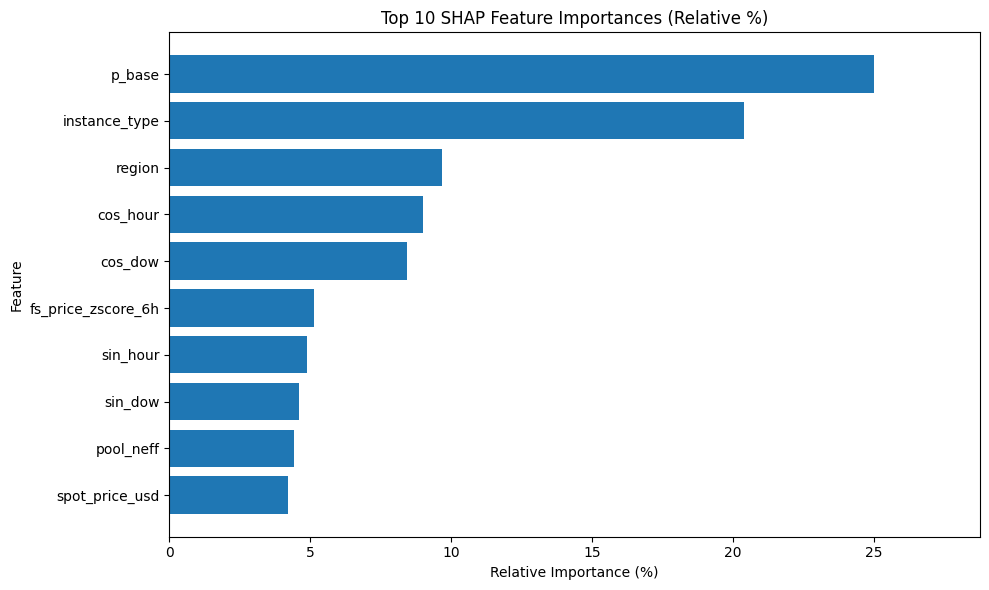

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 10 features and their relative SHAP importance percentages
data = {
    "feature": [
        "p_base",
        "instance_type",
        "region",
        "cos_hour",
        "cos_dow",
        "fs_price_zscore_6h",
        "sin_hour",
        "sin_dow",
        "pool_neff",
        "spot_price_usd"
    ],
    "relative_importance": [
        25.02,
        20.38,
        9.68,
        8.99,
        8.42,
        5.13,
        4.89,
        4.61,
        4.44,
        4.22
    ]
}

df = pd.DataFrame(data)

df = df.sort_values("relative_importance", ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(df["feature"], df["relative_importance"])

plt.xlabel("Relative Importance (%)")
plt.ylabel("Feature")
plt.title("Top 10 SHAP Feature Importances (Relative %)")
plt.xlim(0, max(df["relative_importance"]) * 1.15)


plt.tight_layout()
plt.show()

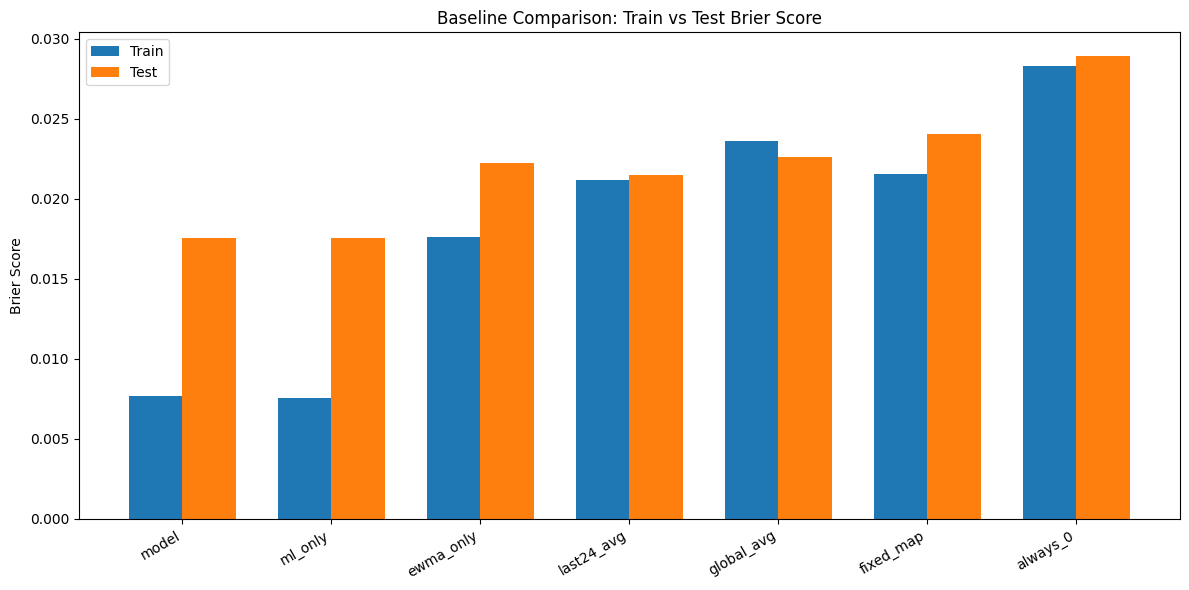

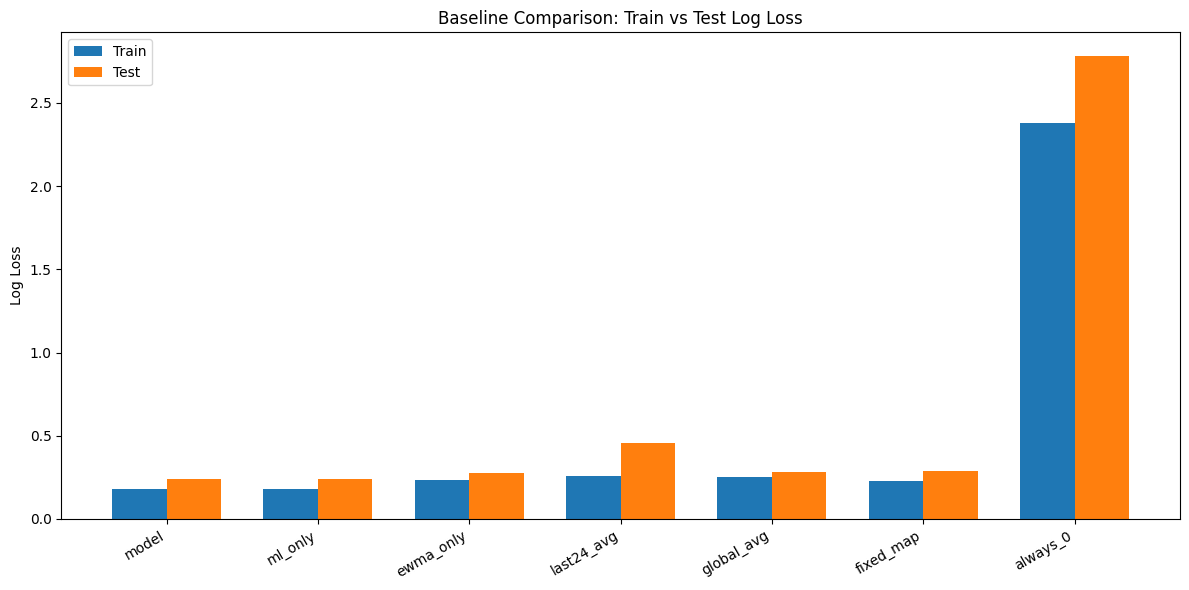

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Baseline comparison metrics
# ============================================================

models = [
    "model",
    "ml_only",
    "ewma_only",
    "last24_avg",
    "global_avg",
    "fixed_map",
    "always_0",
]

# TRAIN_CORE metrics
train_brier = [
    0.007657,  # model
    0.007539,  # ml_only
    0.017624,  # ewma_only
    0.021138,  # last24_avg
    0.023582,  # global_avg
    0.021563,  # fixed_map
    0.028319,  # always_0
]

train_logloss = [
    0.181530,  # model
    0.180893,  # ml_only
    0.232565,  # ewma_only
    0.254851,  # last24_avg
    0.250665,  # global_avg
    0.228970,  # fixed_map
    2.377833,  # always_0
]

# TEST metrics
test_brier = [
    0.017553,  # model
    0.017539,  # ml_only
    0.022210,  # ewma_only
    0.021502,  # last24_avg
    0.022625,  # global_avg
    0.024056,  # fixed_map
    0.028947,  # always_0
]

test_logloss = [
    0.241171,  # model
    0.241047,  # ml_only
    0.276460,  # ewma_only
    0.455758,  # last24_avg
    0.281728,  # global_avg
    0.286628,  # fixed_map
    2.785544,  # always_0
]

x = np.arange(len(models))
width = 0.36

# ============================================================
# Brier Score plot
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_brier, width, label="Train")
plt.bar(x + width/2, test_brier, width, label="Test")

plt.xticks(x, models, rotation=30, ha="right")
plt.ylabel("Brier Score")
plt.title("Baseline Comparison: Train vs Test Brier Score")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Log Loss plot
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_logloss, width, label="Train")
plt.bar(x + width/2, test_logloss, width, label="Test")

plt.xticks(x, models, rotation=30, ha="right")
plt.ylabel("Log Loss")
plt.title("Baseline Comparison: Train vs Test Log Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# Extra helpers for direct-model comparison
# ============================================================
def feature_lists_direct():
    # direct ML model does NOT use p_base or pool_neff
    cat_all = ["provider", "region", "instance_type"]
    num_all = [
        "slice_k",
        "sin_hour", "cos_hour", "sin_dow", "cos_dow",
        "is_weekend",
        "spot_price_usd",
        "fs_price_zscore_6h",
        "fs_launch_local_hour", "fs_launch_utc_hour",
        "tod_bin",
    ]
    return cat_all, num_all


def predict_direct_prob(model, X):
    p = model.predict(X)
    p = np.where(np.isfinite(p), p, 0.0)
    return np.clip(p, EPS, 1.0 - EPS)


def print_metrics_row(name, y_rate, y_bin, p_pred):
    print(
        f"{name:<30} | "
        f"Brier={brier_fractional(y_rate, p_pred):.6f} | "
        f"LogLoss={log_loss_fractional(y_rate, p_pred):.6f} | "
        f"MAE={mae_fractional(y_rate, p_pred):.6f} | "
        f"ECE={ece_score(y_rate, p_pred, n_bins=ECE_BINS):.6f} | "
        f"AUC={auc_safe(y_bin, p_pred):.3f}"
    )


def plot_comparison_bar_chart(metric_name, current_train, current_test, direct_train, direct_test):
    models = ["Model", "Direct ML"]
    train_vals = [current_train, direct_train]
    test_vals = [current_test, direct_test]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(9, 6))
    plt.bar(x - width / 2, train_vals, width, label="Train")
    plt.bar(x + width / 2, test_vals, width, label="Test")

    plt.xticks(x, models)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name}: Model vs Direct ML")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def warm_start_ewmas(history_df, block_hours, global_fallback):
    hist = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
    pending = deque()

    for i in range(len(hist)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(hist.loc[j, TARGET_RATE_COL])
            k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
            ew_pool.update_one(k, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

    mu_g, _ = ew_glob.get(("__global__",))
    if mu_g is None:
        ew_glob.mu[("__global__",)] = float(np.clip(global_fallback, EPS, 1.0 - EPS))
        ew_glob.neff[("__global__",)] = 0.0
        ew_glob.last_t[("__global__",)] = (
            pd.to_datetime(hist[EVENT_TIME_COL].iloc[-1], utc=True)
            if len(hist) else pd.Timestamp.utcnow().tz_localize("UTC")
        )
    return ew_pool, ew_glob


def warm_start_last24(history_df, block_hours, window_h):
    hist = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

    wm_pool = OnlineWindowMean(window_h)
    wm_glob = OnlineWindowMean(window_h)
    pending = deque()

    for i in range(len(hist)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(hist.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
            wm_pool.add(k, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

    return wm_pool, wm_glob

Loaded rows: 7511
✅ Run-split sizes: train_full=5827 test=1502 (gap=6h, dropped_runs=182)
Train_full split (gap=6h): train_core=4775 calib=875

global_q (train_core) = 0.067138
[TUNED] best_K=0.000 on CALIB (baseline-only) with Brier=0.013655

MODEL COMPARISON
Current model - TRAIN          | Brier=0.007657 | LogLoss=0.181530 | MAE=0.042453 | ECE=0.019526 | AUC=0.961
Current model - TEST           | Brier=0.017553 | LogLoss=0.241171 | MAE=0.086844 | ECE=0.023494 | AUC=0.771
Direct ML - TRAIN              | Brier=0.008203 | LogLoss=0.184577 | MAE=0.060982 | ECE=0.051209 | AUC=0.918
Direct ML - TEST               | Brier=0.025991 | LogLoss=0.372171 | MAE=0.114644 | ECE=0.067756 | AUC=0.720

SUMMARY TABLE
        model  train_logloss  test_logloss  train_brier  test_brier
Current model       0.181530      0.241171     0.007657    0.017553
    Direct ML       0.184577      0.372171     0.008203    0.025991


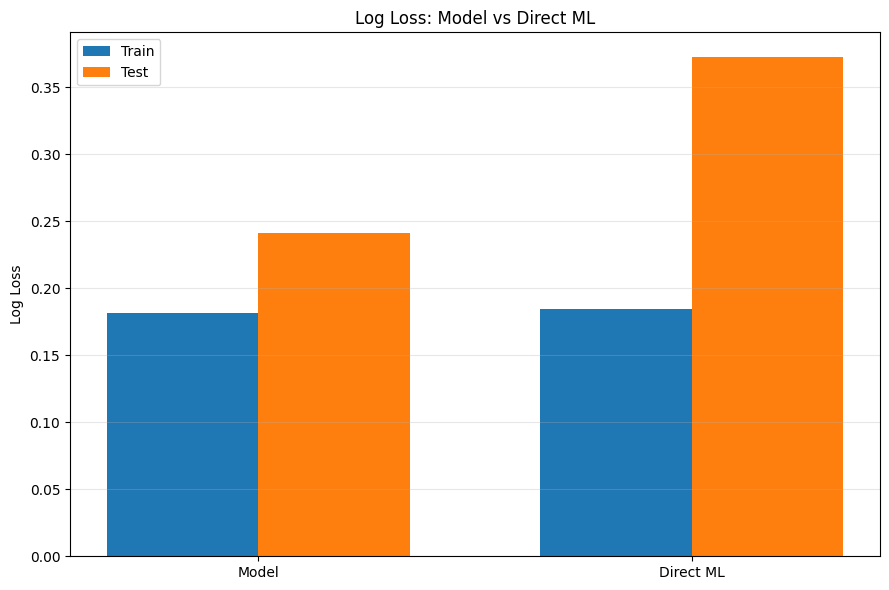

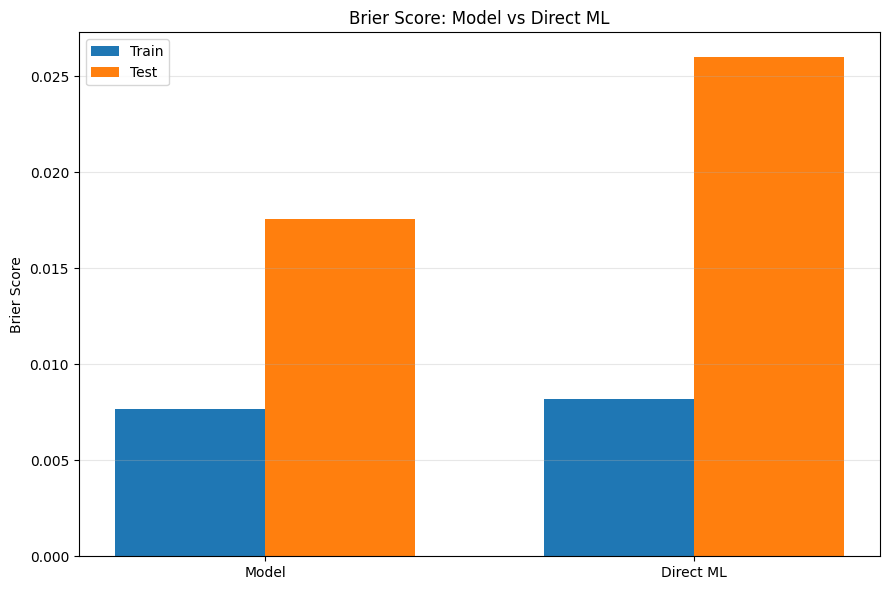

In [33]:
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--block-hours", type=int, default=6)
    args = parser.parse_args([])
    block_hours = args.block_hours

    # ------------------------------------------------------------
    # Load and prepare data
    # ------------------------------------------------------------
    df_raw = load_raw(CSV_PATH)
    slices = make_hour_slices(df_raw)
    if len(slices) == 0:
        print("No sliceable rows found.")
        return

    d = add_time_features(slices.copy().reset_index(drop=True))
    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    train_full_raw, test_raw = time_split_by_run_with_gap(d, TEST_FRACTION, block_hours)
    train_core_raw, calib_raw = split_train_full_into_core_gap_calib(
        train_full_raw, block_hours, CALIB_FRACTION_WITHIN_TRAIN_FULL
    )

    train_core = add_pool_block_rate_target_within_df(train_core_raw, block_hours)
    calib = add_pool_block_rate_target_within_df(calib_raw, block_hours)
    test = add_pool_block_rate_target_within_df(test_raw, block_hours)

    train_core = train_core[train_core[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    calib = calib[calib[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    test = test[test[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)

    train_core = train_core.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    calib = calib.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    test = test.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    global_q = compute_global_q(train_core)
    print(f"\nglobal_q (train_core) = {global_q:.6f}")

    # ------------------------------------------------------------
    # Build baseline features for current model
    # ------------------------------------------------------------
    tr_pool_mu, tr_glob_mu, tr_neff = build_online_ewma_features(train_core, block_hours, global_q)
    ca_pool_mu, ca_glob_mu, ca_neff = build_online_ewma_features(calib, block_hours, global_q)

    train_core["p_ewma"] = np.clip(tr_pool_mu, EPS, 1.0 - EPS)
    calib["p_ewma"] = np.clip(ca_pool_mu, EPS, 1.0 - EPS)

    bestK = {"K": None, "brier": float("inf")}
    y_cal_rate_raw = calib[TARGET_RATE_COL].astype(float).values
    for K in K_GRID:
        p_base_tmp = np.array([
            shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K)
            for i in range(len(calib))
        ])
        B = brier_fractional(y_cal_rate_raw, p_base_tmp)
        if B < bestK["brier"]:
            bestK = {"K": float(K), "brier": float(B)}
    K_star = bestK["K"]
    print(f"[TUNED] best_K={K_star:.3f} on CALIB (baseline-only) with Brier={bestK['brier']:.6f}")

    train_core["pool_neff"] = tr_neff
    calib["pool_neff"] = ca_neff
    train_core["p_base"] = [
        shrink_pool_to_global(tr_pool_mu[i], tr_glob_mu[i], tr_neff[i], K_star)
        for i in range(len(train_core))
    ]
    calib["p_base"] = [
        shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K_star)
        for i in range(len(calib))
    ]

    train_core["p_fixed"] = fixed_lookup_series(train_core, global_q)
    calib["p_fixed"] = fixed_lookup_series(calib, global_q)
    test["p_fixed"] = fixed_lookup_series(test, global_q)

    train_core["p_last24"] = build_last24_baseline_prequential(
        train_core, block_hours, global_q, window_h=LAST24_WINDOW_H
    )
    calib["p_last24"] = build_last24_baseline_prequential(
        calib, block_hours, global_q, window_h=LAST24_WINDOW_H
    )

    # ------------------------------------------------------------
    # CURRENT MODEL: baseline + residual ML + mixture + temperature
    # ------------------------------------------------------------
    cat_cols_resid, num_cols_resid = feature_lists()
    feat_cols_resid = cat_cols_resid + num_cols_resid

    for c in feat_cols_resid:
        for df_ in (train_core, calib, test):
            if c not in df_.columns:
                df_[c] = np.nan

    X_core_resid = build_X(train_core, feat_cols_resid, cat_cols_resid)
    master_cols_resid = X_core_resid.columns

    y_core = np.clip(train_core[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    y_cal = np.clip(calib[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)

    base_core = np.clip(train_core["p_base"].astype(float).values, EPS, 1.0 - EPS)
    base_cal = np.clip(calib["p_base"].astype(float).values, EPS, 1.0 - EPS)

    delta_core = np.clip(logit(y_core) - logit(base_core), -DELTA_CAP, DELTA_CAP)

    current_model = make_model()
    current_model.fit(X_core_resid, delta_core)

    alpha_init = float(FIXED_ALPHA)
    temp_star = float(FIXED_TEMP)

    X_train_eval_resid = build_X(train_core, feat_cols_resid, cat_cols_resid, columns_like=master_cols_resid)
    delta_hat_core = predict_delta(current_model, X_train_eval_resid)
    p_ml_core = p_from_base_and_delta(base_core, delta_hat_core)
    p_current_train = apply_temperature(mix_probs(base_core, p_ml_core, alpha_init), temp_star)

    # ------------------------------------------------------------
    # DIRECT ML MODEL: predict termination rate directly
    # ------------------------------------------------------------
    cat_cols_direct, num_cols_direct = feature_lists_direct()
    feat_cols_direct = cat_cols_direct + num_cols_direct

    for c in feat_cols_direct:
        for df_ in (train_core, calib, test):
            if c not in df_.columns:
                df_[c] = np.nan

    X_core_direct = build_X(train_core, feat_cols_direct, cat_cols_direct)
    master_cols_direct = X_core_direct.columns

    direct_model = make_model()
    direct_model.fit(X_core_direct, y_core)

    X_train_direct = build_X(train_core, feat_cols_direct, cat_cols_direct, columns_like=master_cols_direct)
    p_direct_train_raw = predict_direct_prob(direct_model, X_train_direct)
    p_direct_train = apply_temperature(p_direct_train_raw, temp_star)

    # ------------------------------------------------------------
    # TEST SET evaluation
    # current model uses frozen online baseline updates
    # direct model is just frozen direct prediction
    # ------------------------------------------------------------
    history = pd.concat([train_core, calib], axis=0).sort_values(EVENT_TIME_COL).reset_index(drop=True)

    ew_pool, ew_glob = warm_start_ewmas(history, block_hours, global_q)
    wm_pool, wm_glob = warm_start_last24(history, block_hours, LAST24_WINDOW_H)

    test_sorted = test.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(test_sorted[EVENT_TIME_COL], utc=True).values
    pending = deque()

    p_current_test = np.zeros(len(test_sorted), float)
    p_direct_test = np.zeros(len(test_sorted), float)

    def one_row_features_direct(df_row, feat_cols):
        out = df_row.copy()
        for c in feat_cols:
            if c not in out.columns:
                out[c] = np.nan
        return out[feat_cols]

    for i in range(len(test_sorted)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            yj = float(np.clip(test_sorted.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            kj = tuple(test_sorted.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(kj, t_j, yj)
            ew_glob.update_one(("__global__",), t_j, yj)

            wm_pool.add(kj, t_j, yj)
            wm_glob.add(("__global__",), t_j, yj)

        # ---------- current model ----------
        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_q

        k_i = tuple(test_sorted.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        pool_neff_i = float(max(0.0, ne_p))
        p_base_i = shrink_pool_to_global(float(mu_p), float(mu_g), pool_neff_i, K_star)

        row_current = test_sorted.iloc[[i]].copy()
        row_current["pool_neff"] = pool_neff_i
        row_current["p_base"] = p_base_i

        X_i_resid = build_X(
            one_row_features_direct(row_current, feat_cols_resid),
            feat_cols_resid,
            cat_cols_resid,
            columns_like=master_cols_resid,
        )
        delta_hat_i = float(predict_delta(current_model, X_i_resid)[0])
        p_ml_i = float(p_from_base_and_delta(p_base_i, delta_hat_i))
        p_mix_i = mix_probs(p_base_i, p_ml_i, alpha_init)
        p_current_test[i] = float(apply_temperature(np.array([p_mix_i]), temp_star)[0])

        # ---------- direct model ----------
        row_direct = test_sorted.iloc[[i]].copy()
        X_i_direct = build_X(
            one_row_features_direct(row_direct, feat_cols_direct),
            feat_cols_direct,
            cat_cols_direct,
            columns_like=master_cols_direct,
        )
        p_dir_i_raw = float(predict_direct_prob(direct_model, X_i_direct)[0])
        p_direct_test[i] = float(apply_temperature(np.array([p_dir_i_raw]), temp_star)[0])

    # ------------------------------------------------------------
    # Metrics summary
    # ------------------------------------------------------------
    y_test = np.clip(test_sorted[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)

    current_train_logloss = log_loss_fractional(y_core, p_current_train)
    current_test_logloss = log_loss_fractional(y_test, p_current_test)
    current_train_brier = brier_fractional(y_core, p_current_train)
    current_test_brier = brier_fractional(y_test, p_current_test)

    direct_train_logloss = log_loss_fractional(y_core, p_direct_train)
    direct_test_logloss = log_loss_fractional(y_test, p_direct_test)
    direct_train_brier = brier_fractional(y_core, p_direct_train)
    direct_test_brier = brier_fractional(y_test, p_direct_test)

    print("\n========================================================")
    print("MODEL COMPARISON")
    print("========================================================")
    print_metrics_row(
        "Current model - TRAIN",
        y_core,
        train_core[TARGET_BIN_COL].astype(int).values,
        p_current_train,
    )
    print_metrics_row(
        "Current model - TEST",
        y_test,
        test_sorted[TARGET_BIN_COL].astype(int).values,
        p_current_test,
    )
    print_metrics_row(
        "Direct ML - TRAIN",
        y_core,
        train_core[TARGET_BIN_COL].astype(int).values,
        p_direct_train,
    )
    print_metrics_row(
        "Direct ML - TEST",
        y_test,
        test_sorted[TARGET_BIN_COL].astype(int).values,
        p_direct_test,
    )

    summary_df = pd.DataFrame({
        "model": ["Current model", "Direct ML"],
        "train_logloss": [current_train_logloss, direct_train_logloss],
        "test_logloss": [current_test_logloss, direct_test_logloss],
        "train_brier": [current_train_brier, direct_train_brier],
        "test_brier": [current_test_brier, direct_test_brier],
    })

    print("\n========================================================")
    print("SUMMARY TABLE")
    print("========================================================")
    print(summary_df.to_string(index=False))

    # ------------------------------------------------------------
    # Charts
    # ------------------------------------------------------------
    plot_comparison_bar_chart(
        metric_name="Log Loss",
        current_train=current_train_logloss,
        current_test=current_test_logloss,
        direct_train=direct_train_logloss,
        direct_test=direct_test_logloss,
    )

    plot_comparison_bar_chart(
        metric_name="Brier Score",
        current_train=current_train_brier,
        current_test=current_test_brier,
        direct_train=direct_train_brier,
        direct_test=direct_test_brier,
    )

if __name__ == "__main__":
    main()